1. VERİ SETİNİN YÜKLENMESİ

Veri seti adı: wine
X şekli: (178, 13)
y şekli: (178,)

İlk 5 satır:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39          

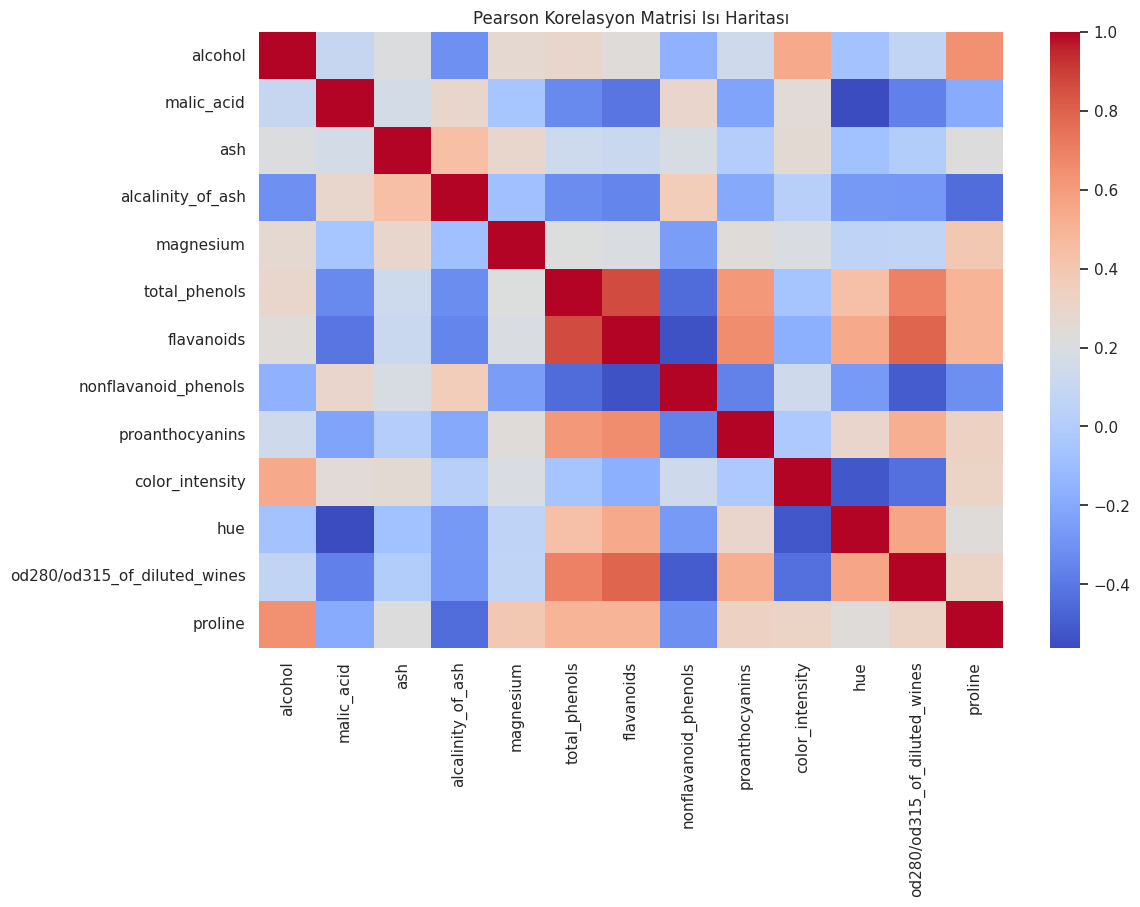


En yüksek korelasyonlu 3 özellik çifti:
flavanoids - total_phenols : 0.8646
flavanoids - od280/od315_of_diluted_wines : 0.7872
od280/od315_of_diluted_wines - total_phenols : 0.6999

Yorum:
- Yüksek korelasyonlu değişkenler benzer bilgi taşıyabilir.
- Bu durum çoklu doğrusal bağlantıya yol açabilir.
- PCA bu fazlalığı azaltmada yararlı olabilir.

3.3 Boxplot Analizi


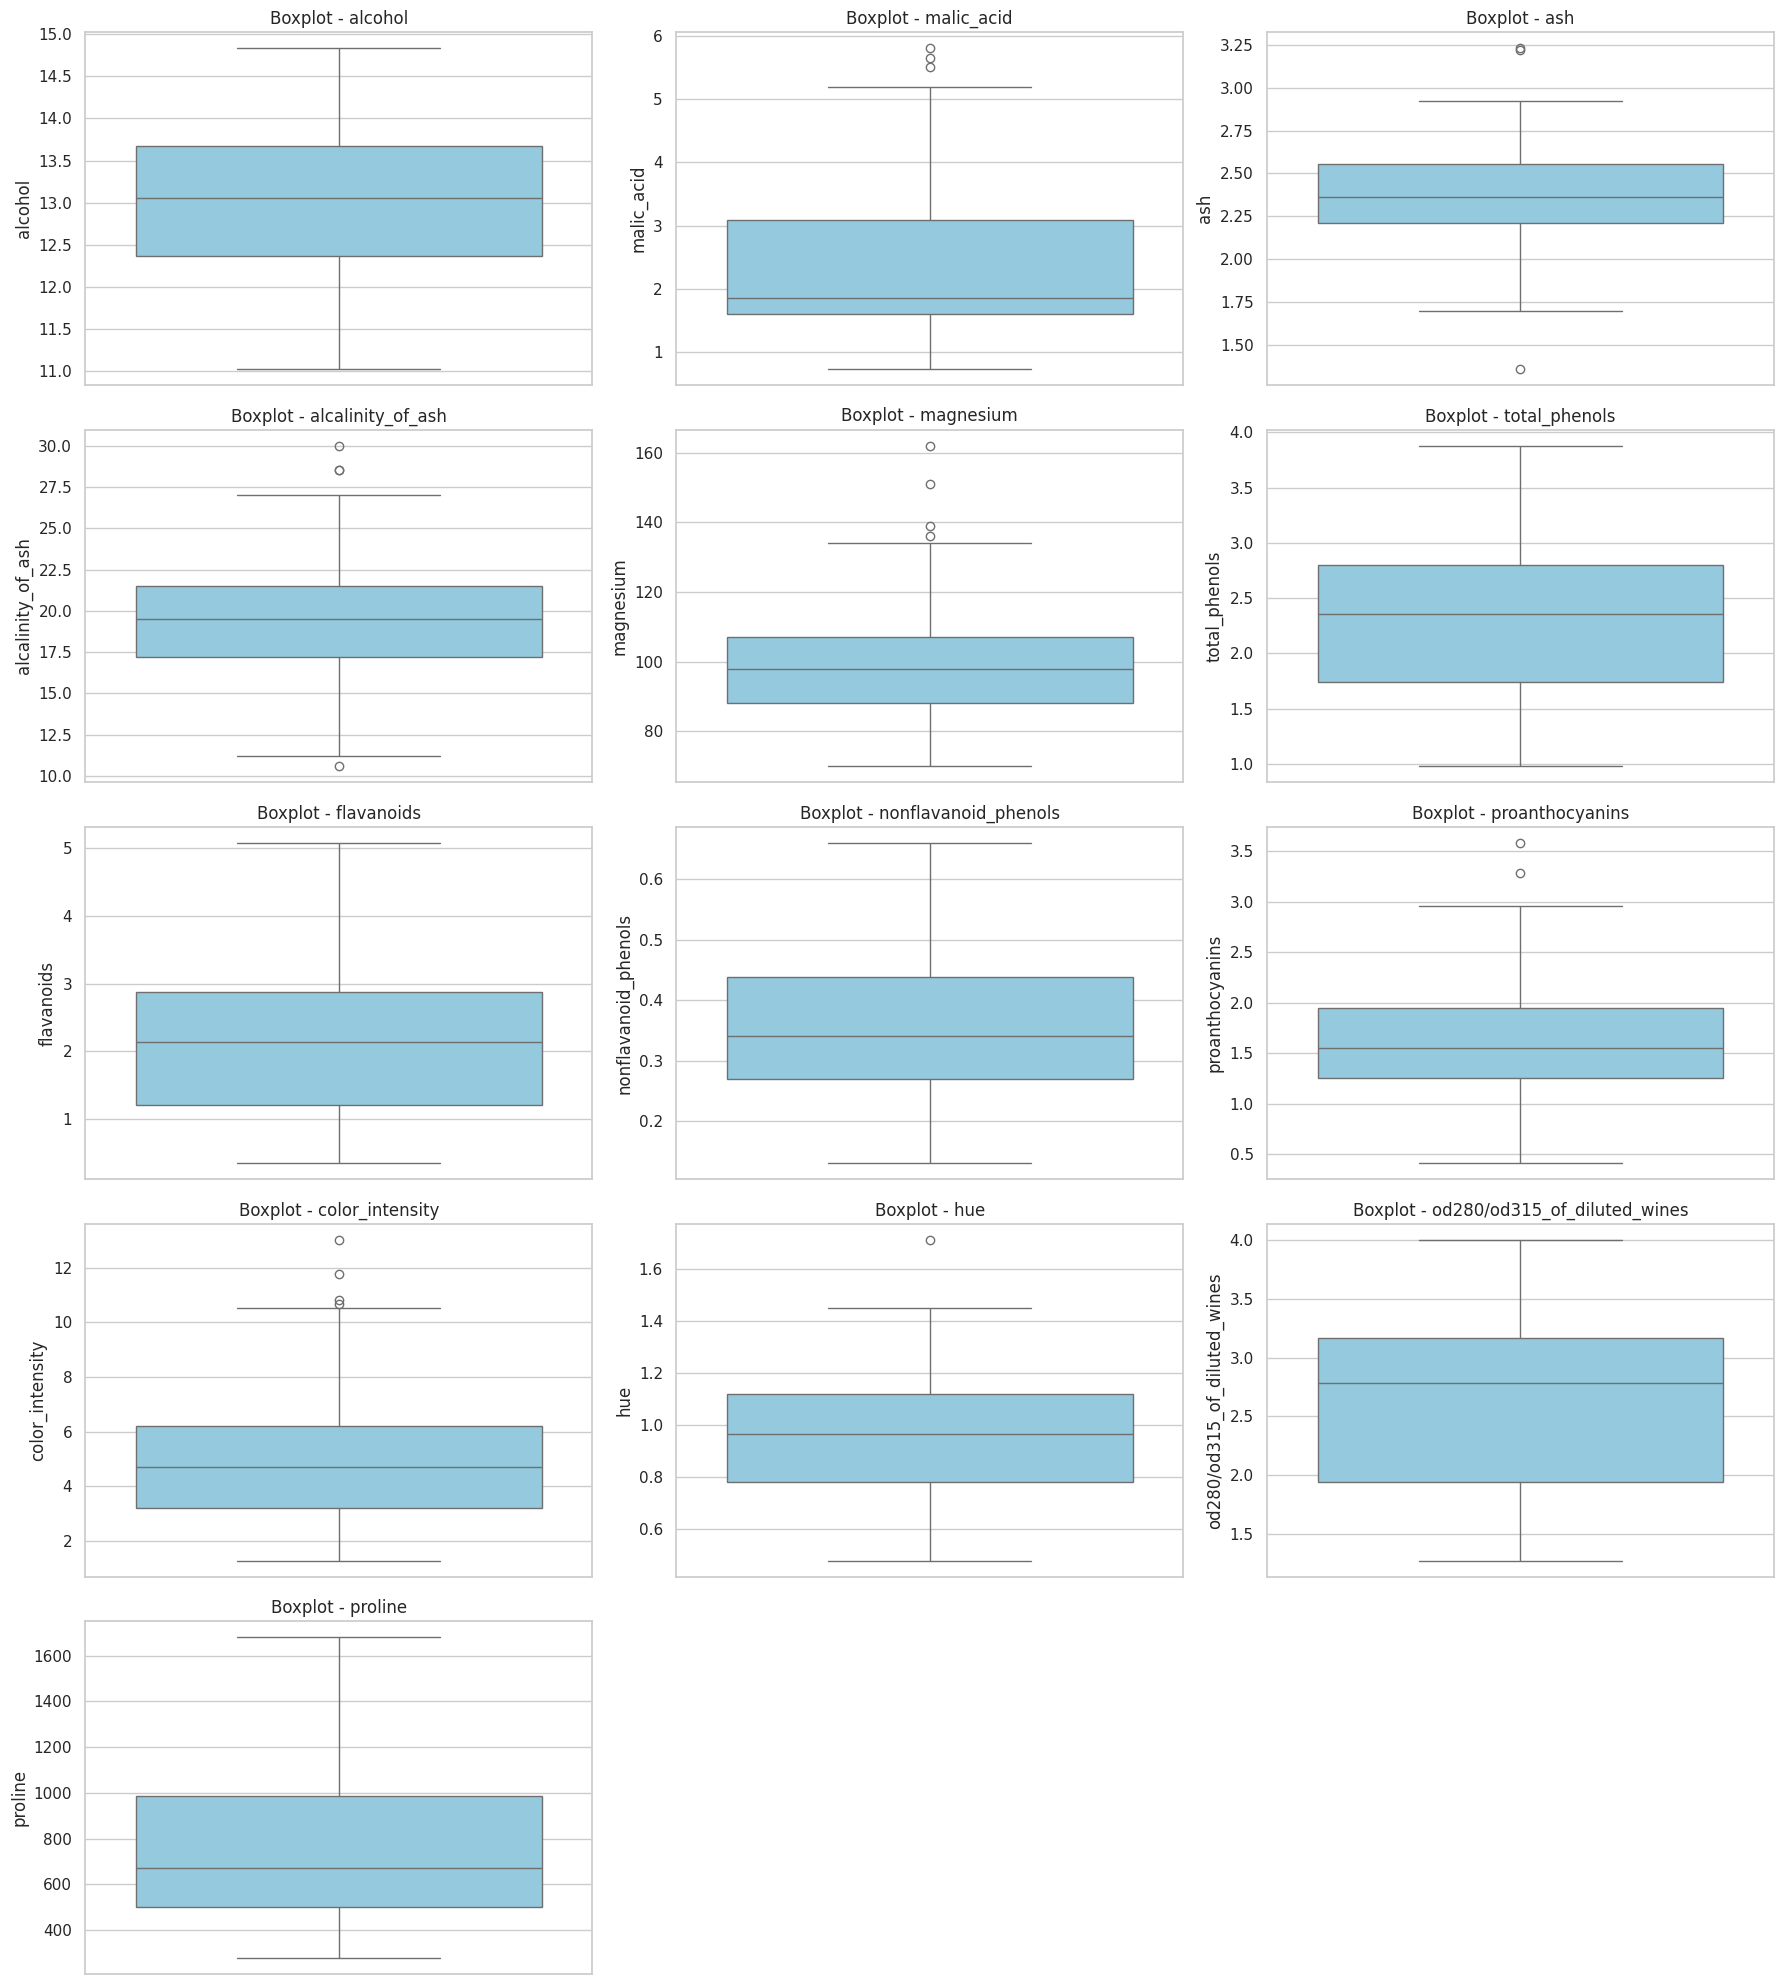


Kısa yorum:
- Boxplot grafiklerinde bazı özelliklerde uç gözlemler görülmektedir.
- Özellikle farklı ölçeklerdeki değişkenlerde dağılım farkı belirgindir.
- Bu nedenle modelleme öncesi ölçekleme önemlidir.

4. VERİ SETİNİN BÖLÜNMESİ
Train boyutu : (124, 13)
Validation boyutu : (18, 13)
Test boyutu : (36, 13)

Kısa yorum:
- Veri istenen oranlara uygun biçimde bölündü.
- Stratify kullanıldığı için sınıf dağılımı korunmuştur.

5. VERİ ÖLÇEKLENDİRME
X_scaled şekli: (178, 13)

Kısa yorum:
- StandardScaler kullanıldı.
- Özellikler ortalama=0 ve std=1 olacak şekilde ölçeklendi.
- Bu adım PCA, LDA, Logistic Regression ve Naive Bayes için önemlidir.

6. ÖZELLİK SEÇİMİ VE BOYUT İNDİRGEME

6.1 PCA
Explained variance ratio ortalaması: 0.07692307692307693
Bu ortalamadan büyük bileşen sayısı: 3


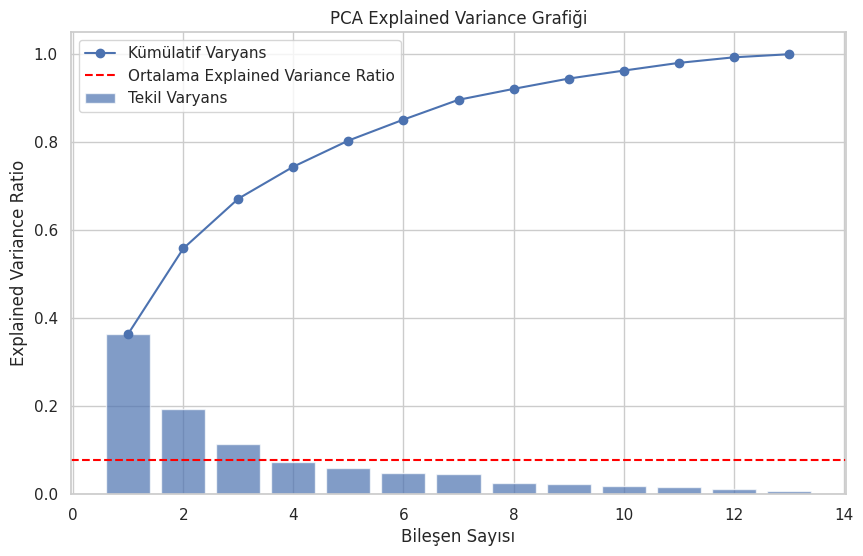

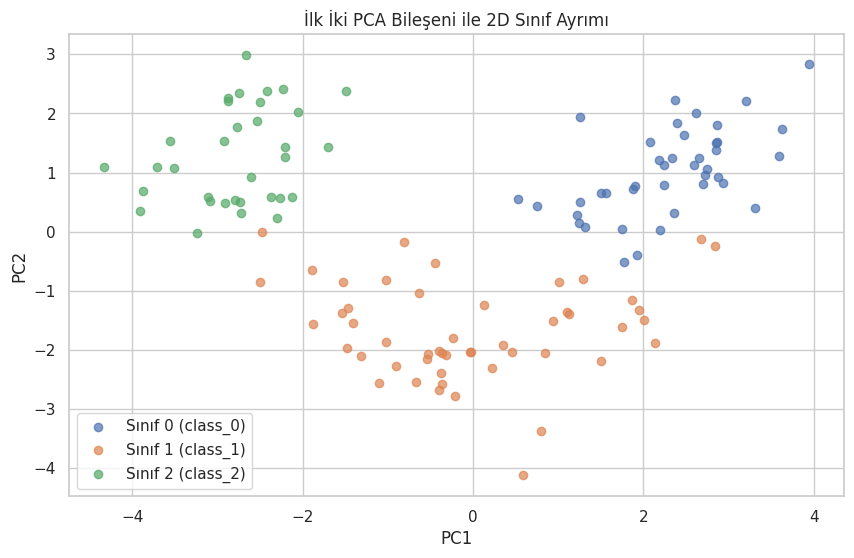


PCA yorumu:
- PCA, değişkenleri doğrusal birleşimlerle daha az boyutta temsil etti.
- İlk iki bileşen sınıfların genel ayrımını görsel olarak incelemeyi sağladı.
- Yüksek varyans taşıyan bilgi daha az boyutta korunmuş oldu.

6.2 LDA
Uyarı: LDA için n_components=3 bu veri setinde mümkün değil.
Kullanılabilecek maksimum bileşen sayısı: 2
Bu nedenle LDA bu maksimum değer ile çalıştırılacaktır.


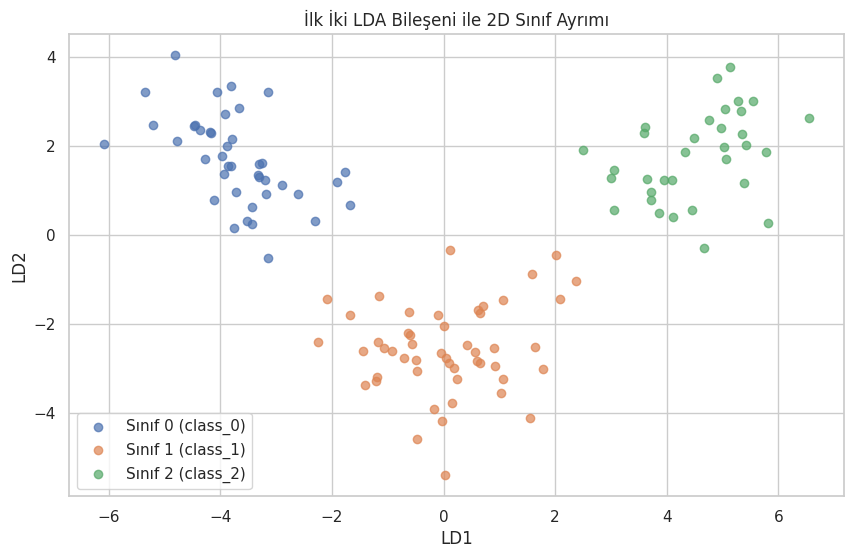


LDA yorumu:
- LDA, sınıfları ayırmaya yönelik doğrusal eksenler üretir.
- PCA’dan farklı olarak varyansı değil sınıf ayrımını maksimize eder.
- Bu nedenle sınıflandırma performansını artırma potansiyeli vardır.

7. MAKİNE ÖĞRENMESİ MODELLERİNİN KURULMASI

>>> Veri temsili: Raw
Logistic Regression  | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000
Decision Tree        | Acc=0.9444 | F1=0.9438 | ROC-AUC=0.9545
Random Forest        | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000
XGBoost              | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000
GaussianNB           | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000

>>> Veri temsili: PCA
Logistic Regression  | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000
Decision Tree        | Acc=0.8889 | F1=0.8889 | ROC-AUC=0.9129
Random Forest        | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000
XGBoost              | Acc=0.9444 | F1=0.9438 | ROC-AUC=1.0000
GaussianNB           | Acc=1.0000 | F1=1.0000 | ROC-AUC=1.0000

>>> Veri temsili: LDA
Logistic Regression  | Acc=1.0000 | F1=1.0000

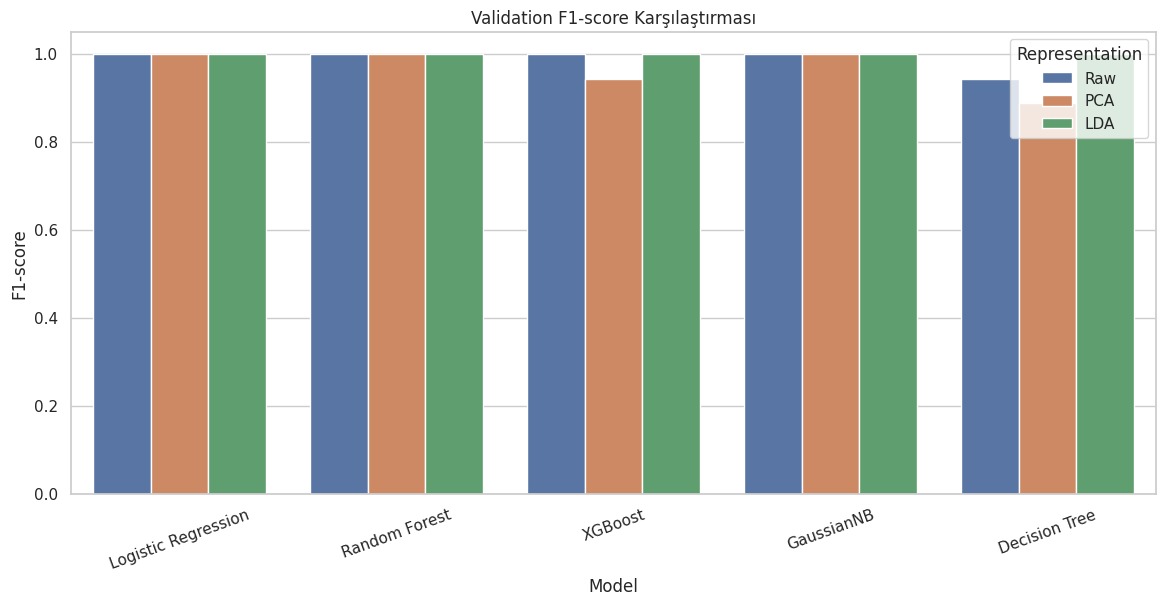


En iyi validation modeli:
Representation                    Raw
Model             Logistic Regression
Accuracy                          1.0
Precision                         1.0
Recall                            1.0
F1-score                          1.0
ROC-AUC                           1.0
Name: 0, dtype: object

Kısa yorum:
- Modeller F1-score öncelikli, ardından ROC-AUC ve Accuracy ile sıralandı.
- En iyi model validation başarısına göre test aşamasında ayrıca değerlendirilecektir.

9. EN İYİ MODELİN TEST ÜZERİNDE DEĞERLENDİRİLMESİ

Test metrikleri:
Accuracy : 0.9722
Precision: 0.9741
Recall   : 0.9722
F1-score : 0.9720
ROC-AUC  : 1.0000


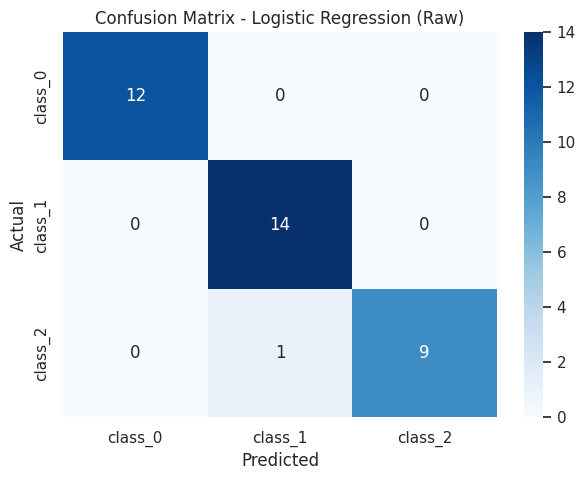

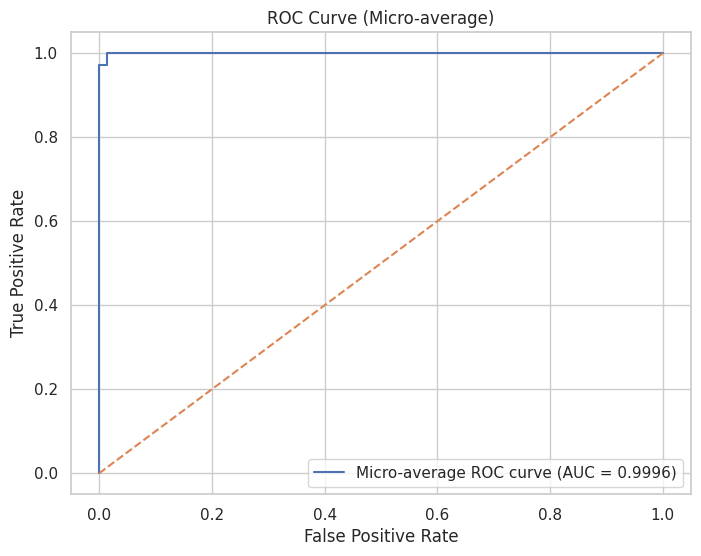


Threshold yorumu:
- Threshold düştükçe model daha fazla pozitif tahmin yapar; recall artabilir, precision düşebilir.
- Threshold yükseldikçe model daha seçici olur; precision artabilir, recall düşebilir.
- ROC eğrisi bu dengeyi farklı eşiklerde gösterir.

Kısa yorum:
- En iyi validation modeli test verisinde ayrıca doğrulandı.
- Confusion matrix sınıf bazlı hataları gösterdi.
- ROC eğrisi modelin eşik değişimlerine karşı davranışını özetledi.

10. XAI - SHAP AÇIKLANABİLİRLİK ANALİZİ

10.1 En İyi Validation Modeli için SHAP Analizi
Seçilen model: Logistic Regression | Temsil: Raw

Best Model (Logistic Regression - Raw) SHAP analizi başlatıldı...


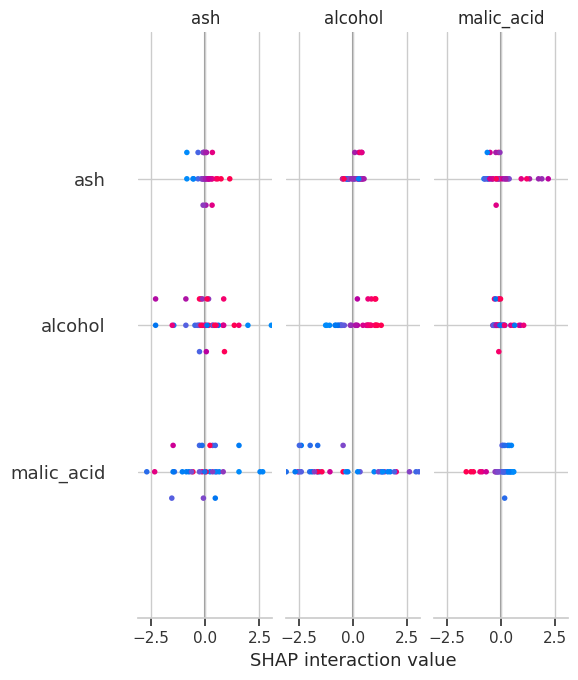


Best Model (Logistic Regression - Raw) - En önemli özellikler:
                         Feature  MeanAbsSHAP
12                       proline     0.619305
6                     flavanoids     0.598780
9                color_intensity     0.585888
0                        alcohol     0.555719
11  od280/od315_of_diluted_wines     0.468039
10                           hue     0.443736
3              alcalinity_of_ash     0.428226
2                            ash     0.419574
1                     malic_acid     0.271329
8                proanthocyanins     0.267302


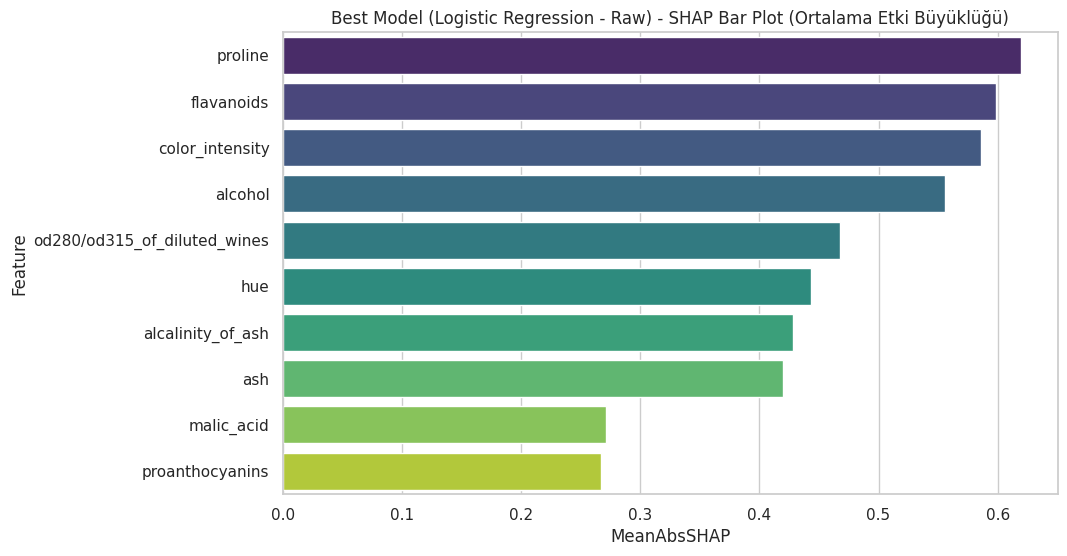


Yorum:
- SHAP summary plot, özelliklerin tahmine olan yönünü ve büyüklüğünü gösterir.
- Bar plot ise ortalama mutlak katkıya göre en önemli değişkenleri sıralar.
- Model performansı yüksekse, SHAP ile görülen baskın özellikler karar mekanizmasını anlamada güçlü ipucu verir.

10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması

PCA için en iyi model: Logistic Regression

PCA Best Model (Logistic Regression) SHAP analizi başlatıldı...


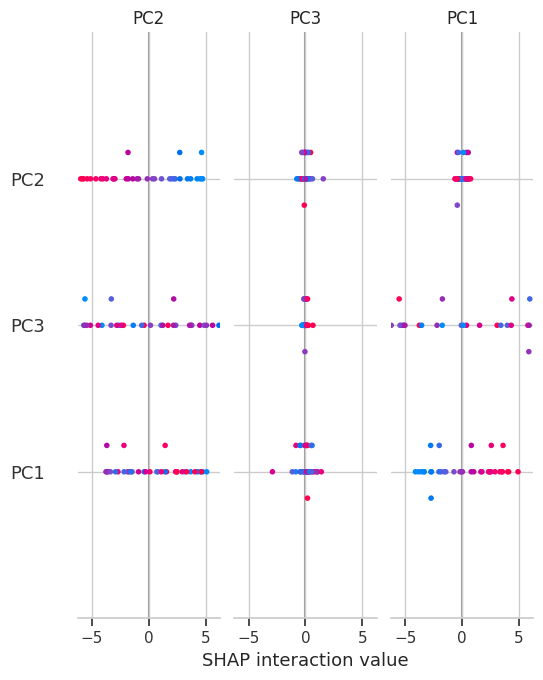


PCA Best Model (Logistic Regression) - En önemli özellikler:
  Feature  MeanAbsSHAP
1     PC2     2.134628
0     PC1     1.741016
2     PC3     0.165690


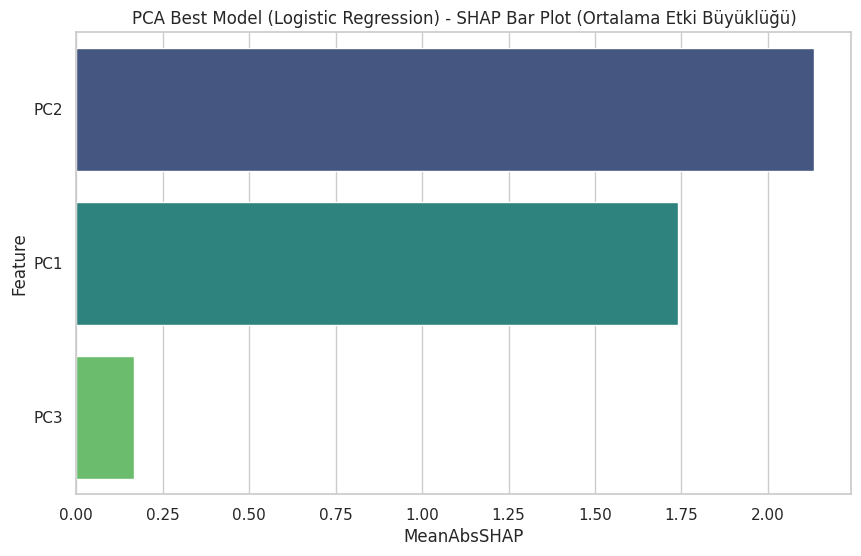


LDA için en iyi model: Logistic Regression

LDA Best Model (Logistic Regression) SHAP analizi başlatıldı...
Summary plot üretilemedi: index 2 is out of bounds for axis 1 with size 2

LDA Best Model (Logistic Regression) - En önemli özellikler:
  Feature  MeanAbsSHAP
0     LD1     2.569505
1     LD2     2.232208


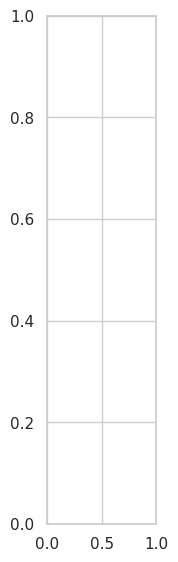

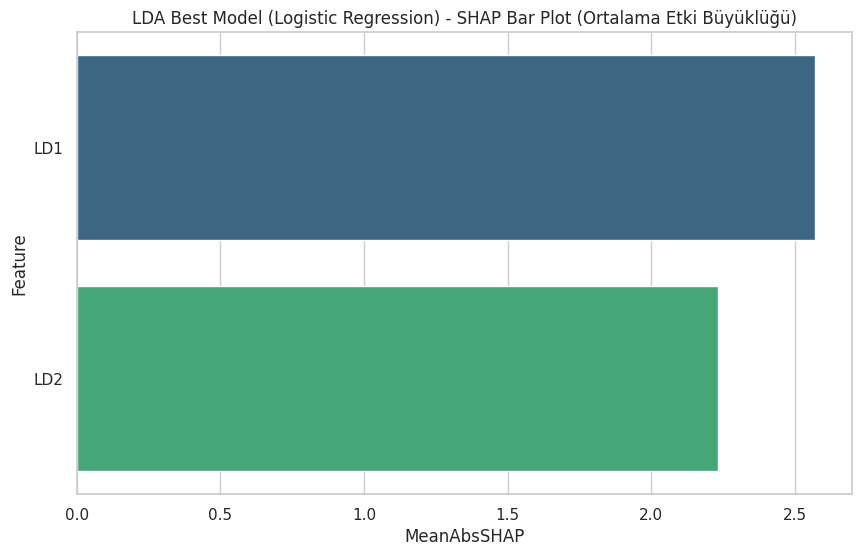


PCA ve LDA için tartışma:
- PCA bileşenleri varyansı koruyan doğrusal birleşimlerdir; SHAP burada hangi ana varyans yönlerinin önemli olduğunu gösterir.
- LDA bileşenleri sınıf ayrımını maksimize eder; SHAP burada sınıf ayırıcı eksenlerin etkisini gösterir.
- Eğer LDA bileşenleri daha baskın görünüyorsa, sınıf ayrımı için denetimli indirgeme daha faydalı olmuş olabilir.
- Eğer PCA bileşenleri daha güçlü görünüyorsa, verinin doğal varyans yapısı sınıflandırmada yeterince açıklayıcı olabilir.

SONUÇ ÖZETİ

1) Veri seti başarıyla yüklendi ve kalite kontrolleri yapıldı.
2) Eksik değer ve aykırı değer analizleri gerçekleştirildi.
3) EDA kapsamında istatistiksel özet, korelasyon matrisi ve boxplotlar incelendi.
4) Veri %70 train, %10 validation, %20 test olarak bölündü.
5) StandardScaler ile ölçekleme yapıldı.
6) Ham veri, PCA ve LDA olmak üzere 3 veri temsili üretildi.
7) Her temsil için 5 model kurularak toplam 15 model eğitildi.
8) Validation sonuçları karşılaştırıldı ve en iyi model seç

In [1]:
# ============================================================
# MAKİNE ÖĞRENMESİ ARA SINAV ÖDEVİ
# Klasik ML + PCA + LDA + XAI (SHAP)
# Veri Seti: Wine Classification
# ============================================================

# Eğer Colab / Jupyter ortamında bazı kütüphaneler eksikse aç:
# !pip install xgboost shap seaborn -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)

from xgboost import XGBClassifier
import shap

# Grafik ayarları
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

# ============================================================
# 1. VERİ SETİNİN YÜKLENMESİ
# ============================================================
print("="*80)
print("1. VERİ SETİNİN YÜKLENMESİ")
print("="*80)

# İstenirse breast_cancer da seçilebilir ama bu ödev için wine daha uygundur
dataset_name = "wine"   # "wine" veya "breast_cancer"

if dataset_name == "wine":
    data = load_wine()
else:
    data = load_breast_cancer()

X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("\nVeri seti adı:", dataset_name)
print("X şekli:", X.shape)
print("y şekli:", y.shape)
print("\nİlk 5 satır:")
print(df.head())

print("\nKısa yorum:")
print("- Veri seti başarıyla yüklendi.")
print("- Özellikler pandas DataFrame formatına dönüştürüldü.")
print("- Hedef değişken target sütunu olarak eklendi.")

# ============================================================
# 2. VERİ SETİ KALİTE KONTROLLERİ
# ============================================================
print("\n" + "="*80)
print("2. VERİ SETİ KALİTE KONTROLLERİ")
print("="*80)

# 2.1 Eksik değer analizi
print("\n2.1 Eksik Değer Analizi")
missing_values = df.isnull().sum()
print("\nHer sütundaki eksik değer sayısı:")
print(missing_values)

if missing_values.sum() > 0:
    print("\nEksik değer bulundu. Mean ile dolduruluyor...")
    imputer = SimpleImputer(strategy="mean")
    df_imputed = pd.DataFrame(imputer.fit_transform(df.drop(columns=["target"])),
                              columns=feature_names)
    df_imputed["target"] = df["target"].values
    df = df_imputed.copy()
else:
    print("\nEksik değer bulunmadı. İmputation uygulanmadı.")

# 2.2 Aykırı değer analizi - IQR
print("\n2.2 Aykırı Değer (Outlier) Analizi - IQR")
numeric_cols = df.drop(columns=["target"]).columns

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, Q1, Q3, IQR, lower, upper, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Q1", "Q3", "IQR", "LowerBound", "UpperBound", "OutlierCount"]
)

print("\nOutlier özeti:")
print(outlier_df)

print("\nAykırı değerlerin modele etkisi:")
print("- Aykırı değerler özellikle distance-based veya linear modellerde dağılımı bozabilir.")
print("- Ortalama ve standart sapmayı etkileyerek ölçeklemeyi değiştirebilir.")
print("- Tree tabanlı modeller aykırı değerlere genelde daha dayanıklıdır.")

# 2.3 Veri tipi ve dağılım incelemesi
print("\n2.3 Veri Tipi ve Dağılım İncelemesi")
dtype_info = df.dtypes
print("\nSütun veri tipleri:")
print(dtype_info)

numeric_count = df.drop(columns=["target"]).select_dtypes(include=[np.number]).shape[1]
categorical_count = df.drop(columns=["target"]).select_dtypes(exclude=[np.number]).shape[1]

print(f"\nSayısal değişken sayısı: {numeric_count}")
print(f"Kategorik değişken sayısı: {categorical_count}")
print(f"Hedef sınıf dağılımı:\n{df['target'].value_counts().sort_index()}")

print("\nKısa yorum:")
print("- Bu veri setindeki tüm giriş özellikleri sayısaldır.")
print("- Kategorik giriş değişkeni bulunmamaktadır.")
print("- Hedef değişken sınıf etiketlerinden oluşmaktadır.")

# ============================================================
# 3. EDA
# ============================================================
print("\n" + "="*80)
print("3. KEŞİFSEL VERİ ANALİZİ (EDA)")
print("="*80)

# 3.1 İstatistiksel özellikler
print("\n3.1 İstatistiksel Özellikler")
stats_df = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
    "Std": df[numeric_cols].std(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q3": df[numeric_cols].quantile(0.75),
})
print("\nİstatistiksel özet:")
print(stats_df)

# 3.2 Korelasyon matrisi
print("\n3.2 Korelasyon Matrisi")
corr_matrix = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f")
plt.title("Pearson Korelasyon Matrisi Isı Haritası")
plt.show()

# En yüksek korelasyonlu 3 çift
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # kendisiyle korelasyonu çıkar
top_pairs = corr_pairs.drop_duplicates().head(3)

print("\nEn yüksek korelasyonlu 3 özellik çifti:")
for idx, val in top_pairs.items():
    print(f"{idx[0]} - {idx[1]} : {val:.4f}")

print("\nYorum:")
print("- Yüksek korelasyonlu değişkenler benzer bilgi taşıyabilir.")
print("- Bu durum çoklu doğrusal bağlantıya yol açabilir.")
print("- PCA bu fazlalığı azaltmada yararlı olabilir.")

# 3.3 Boxplot analizi
print("\n3.3 Boxplot Analizi")
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot - {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\nKısa yorum:")
print("- Boxplot grafiklerinde bazı özelliklerde uç gözlemler görülmektedir.")
print("- Özellikle farklı ölçeklerdeki değişkenlerde dağılım farkı belirgindir.")
print("- Bu nedenle modelleme öncesi ölçekleme önemlidir.")

# ============================================================
# 4. VERİ SETİNİN BÖLÜNMESİ (%70 train, %10 val, %20 test)
# ============================================================
print("\n" + "="*80)
print("4. VERİ SETİNİN BÖLÜNMESİ")
print("="*80)

X_all = df.drop(columns=["target"]).copy()
y_all = df["target"].copy()

# Önce %80 train+val, %20 test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

# Kalan %80'in içinden %12.5 validation => toplamın %10'u
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.125,
    random_state=42,
    stratify=y_trainval
)

print("Train boyutu :", X_train.shape)
print("Validation boyutu :", X_val.shape)
print("Test boyutu :", X_test.shape)

print("\nKısa yorum:")
print("- Veri istenen oranlara uygun biçimde bölündü.")
print("- Stratify kullanıldığı için sınıf dağılımı korunmuştur.")

# ============================================================
# 5. VERİ ÖLÇEKLENDİRME
# ============================================================
print("\n" + "="*80)
print("5. VERİ ÖLÇEKLENDİRME")
print("="*80)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X_all)  # ödevde istenen genel ölçeklenmiş veri

print("X_scaled şekli:", X_scaled.shape)

print("\nKısa yorum:")
print("- StandardScaler kullanıldı.")
print("- Özellikler ortalama=0 ve std=1 olacak şekilde ölçeklendi.")
print("- Bu adım PCA, LDA, Logistic Regression ve Naive Bayes için önemlidir.")

# ============================================================
# 6. ÖZELLİK SEÇİMİ VE BOYUT İNDİRGEME
#    1) Ham veri
#    2) PCA verisi
#    3) LDA verisi
# ============================================================
print("\n" + "="*80)
print("6. ÖZELLİK SEÇİMİ VE BOYUT İNDİRGEME")
print("="*80)

# ---------------------------
# 6.1 PCA
# ---------------------------
print("\n6.1 PCA")

# Önce tüm bileşenlerle PCA yapıp explained variance inceleyelim
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_var_ratio = pca_full.explained_variance_ratio_
mean_explained_ratio = explained_var_ratio.mean()

# İstenen kurala göre: explained variance ratio ortalamasından büyük olan bileşen sayısı
n_components_pca = np.sum(explained_var_ratio > mean_explained_ratio)
n_components_pca = max(n_components_pca, 2)  # görselleştirme için en az 2

print("Explained variance ratio ortalaması:", mean_explained_ratio)
print("Bu ortalamadan büyük bileşen sayısı:", n_components_pca)

# PCA'yı seçilen bileşen sayısıyla yeniden kur
pca = PCA(n_components=n_components_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Grafik: explained variance
cum_var = np.cumsum(explained_var_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_var_ratio)+1), explained_var_ratio, alpha=0.7, label="Tekil Varyans")
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o", label="Kümülatif Varyans")
plt.axhline(mean_explained_ratio, color="red", linestyle="--", label="Ortalama Explained Variance Ratio")
plt.xlabel("Bileşen Sayısı")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Grafiği")
plt.legend()
plt.show()

# İlk iki PCA bileşeni scatter
plt.figure(figsize=(10, 6))
for class_id in np.unique(y_train):
    idx = (y_train == class_id)
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        label=f"Sınıf {class_id} ({target_names[class_id]})",
        alpha=0.7
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("İlk İki PCA Bileşeni ile 2D Sınıf Ayrımı")
plt.legend()
plt.show()

print("\nPCA yorumu:")
print("- PCA, değişkenleri doğrusal birleşimlerle daha az boyutta temsil etti.")
print("- İlk iki bileşen sınıfların genel ayrımını görsel olarak incelemeyi sağladı.")
print("- Yüksek varyans taşıyan bilgi daha az boyutta korunmuş oldu.")

# ---------------------------
# 6.2 LDA
# ---------------------------
print("\n6.2 LDA")

max_lda_components = min(3, len(np.unique(y_train)) - 1, X_train_scaled.shape[1])

if max_lda_components < 3:
    print(f"Uyarı: LDA için n_components=3 bu veri setinde mümkün değil.")
    print(f"Kullanılabilecek maksimum bileşen sayısı: {max_lda_components}")
    print("Bu nedenle LDA bu maksimum değer ile çalıştırılacaktır.")

lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

# İlk iki LDA bileşeni scatter
plt.figure(figsize=(10, 6))
for class_id in np.unique(y_train):
    idx = (y_train == class_id)
    x1 = X_train_lda[idx, 0]
    x2 = X_train_lda[idx, 1] if X_train_lda.shape[1] > 1 else np.zeros_like(x1)
    plt.scatter(
        x1, x2,
        label=f"Sınıf {class_id} ({target_names[class_id]})",
        alpha=0.7
    )
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("İlk İki LDA Bileşeni ile 2D Sınıf Ayrımı")
plt.legend()
plt.show()

print("\nLDA yorumu:")
print("- LDA, sınıfları ayırmaya yönelik doğrusal eksenler üretir.")
print("- PCA’dan farklı olarak varyansı değil sınıf ayrımını maksimize eder.")
print("- Bu nedenle sınıflandırma performansını artırma potansiyeli vardır.")

# ============================================================
# 7. MAKİNE ÖĞRENMESİ MODELLERİ
#    5 model x 3 temsil = 15 model
# ============================================================
print("\n" + "="*80)
print("7. MAKİNE ÖĞRENMESİ MODELLERİNİN KURULMASI")
print("="*80)

# Veri temsilleri
representations = {
    "Raw": {
        "X_train": X_train_scaled,
        "X_val": X_val_scaled,
        "X_test": X_test_scaled,
        "feature_names": list(X_train.columns)
    },
    "PCA": {
        "X_train": X_train_pca,
        "X_val": X_val_pca,
        "X_test": X_test_pca,
        "feature_names": [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
    },
    "LDA": {
        "X_train": X_train_lda,
        "X_val": X_val_lda,
        "X_test": X_test_lda,
        "feature_names": [f"LD{i+1}" for i in range(X_train_lda.shape[1])]
    }
}

# Modeller
num_classes = len(np.unique(y_train))

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.7,
        objective="multi:softprob" if num_classes > 2 else "binary:logistic",
        eval_metric="mlogloss" if num_classes > 2 else "logloss",
        random_state=42
    ),
    "GaussianNB": GaussianNB()
}

def evaluate_model(model, Xtr, ytr, Xv, yv, average="weighted"):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xv)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xv)
    else:
        y_proba = None

    acc = accuracy_score(yv, y_pred)
    prec = precision_score(yv, y_pred, average=average, zero_division=0)
    rec = recall_score(yv, y_pred, average=average, zero_division=0)
    f1 = f1_score(yv, y_pred, average=average, zero_division=0)

    if y_proba is not None:
        if len(np.unique(yv)) > 2:
            roc_auc = roc_auc_score(yv, y_proba, multi_class="ovr", average="weighted")
        else:
            roc_auc = roc_auc_score(yv, y_proba[:, 1])
    else:
        roc_auc = np.nan

    return model, acc, prec, rec, f1, roc_auc

results = []
trained_models = {}

for rep_name, rep_data in representations.items():
    print(f"\n>>> Veri temsili: {rep_name}")
    for model_name, model in models.items():
        trained_model, acc, prec, rec, f1, roc_auc = evaluate_model(
            model,
            rep_data["X_train"], y_train,
            rep_data["X_val"], y_val
        )

        results.append({
            "Representation": rep_name,
            "Model": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1,
            "ROC-AUC": roc_auc
        })

        trained_models[(rep_name, model_name)] = trained_model
        print(f"{model_name:20s} | Acc={acc:.4f} | F1={f1:.4f} | ROC-AUC={roc_auc:.4f}")

print("\nKısa yorum:")
print("- Her veri temsili için 5 farklı model eğitildi.")
print("- Böylece toplam 15 model oluşturuldu.")
print("- Validation performansları bir sonraki bölümde karşılaştırılacaktır.")

# ============================================================
# 8. VALIDATION PERFORMANSLARI
# ============================================================
print("\n" + "="*80)
print("8. VALIDATION PERFORMANSLARININ ÖLÇÜLMESİ")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["F1-score", "ROC-AUC", "Accuracy"], ascending=False).reset_index(drop=True)

print("\nValidation sonuç tablosu:")
print(results_df)

plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x="Model", y="F1-score", hue="Representation")
plt.title("Validation F1-score Karşılaştırması")
plt.xticks(rotation=20)
plt.show()

best_row = results_df.iloc[0]
best_representation = best_row["Representation"]
best_model_name = best_row["Model"]
best_model = trained_models[(best_representation, best_model_name)]

print("\nEn iyi validation modeli:")
print(best_row)

print("\nKısa yorum:")
print("- Modeller F1-score öncelikli, ardından ROC-AUC ve Accuracy ile sıralandı.")
print("- En iyi model validation başarısına göre test aşamasında ayrıca değerlendirilecektir.")

# ============================================================
# 9. EN İYİ MODELİN TEST ÜZERİNDE DEĞERLENDİRİLMESİ
# ============================================================
print("\n" + "="*80)
print("9. EN İYİ MODELİN TEST ÜZERİNDE DEĞERLENDİRİLMESİ")
print("="*80)

best_X_train = representations[best_representation]["X_train"]
best_X_val = representations[best_representation]["X_val"]
best_X_test = representations[best_representation]["X_test"]
best_feature_names = representations[best_representation]["feature_names"]

# En iyi modeli train + val birleşik veri üzerinde yeniden eğit
X_best_train_full = np.vstack([best_X_train, best_X_val])
y_best_train_full = np.concatenate([y_train, y_val])

best_model.fit(X_best_train_full, y_best_train_full)

y_test_pred = best_model.predict(best_X_test)
y_test_proba = best_model.predict_proba(best_X_test) if hasattr(best_model, "predict_proba") else None

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_rec = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

if y_test_proba is not None:
    if len(np.unique(y_test)) > 2:
        test_auc = roc_auc_score(y_test, y_test_proba, multi_class="ovr", average="weighted")
    else:
        test_auc = roc_auc_score(y_test, y_test_proba[:, 1])
else:
    test_auc = np.nan

print("\nTest metrikleri:")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall   : {test_rec:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

# 9.2 Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion Matrix - {best_model_name} ({best_representation})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 9.3 ROC Eğrisi
if y_test_proba is not None:
    if len(np.unique(y_test)) > 2:
        # Micro-average ROC
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        fpr, tpr, thresholds = roc_curve(y_test_bin.ravel(), y_test_proba.ravel())
        roc_auc_micro = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"Micro-average ROC curve (AUC = {roc_auc_micro:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve (Micro-average)")
        plt.legend(loc="lower right")
        plt.show()

        print("\nThreshold yorumu:")
        print("- Threshold düştükçe model daha fazla pozitif tahmin yapar; recall artabilir, precision düşebilir.")
        print("- Threshold yükseldikçe model daha seçici olur; precision artabilir, recall düşebilir.")
        print("- ROC eğrisi bu dengeyi farklı eşiklerde gösterir.")
    else:
        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba[:, 1])
        roc_auc_bin = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_bin:.4f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.show()

        print("\nThreshold yorumu:")
        print("- Eşik değeri düştüğünde duyarlılık artar ancak yanlış pozitifler de artabilir.")
        print("- Eşik değeri yükseldiğinde model daha muhafazakar davranır.")

print("\nKısa yorum:")
print("- En iyi validation modeli test verisinde ayrıca doğrulandı.")
print("- Confusion matrix sınıf bazlı hataları gösterdi.")
print("- ROC eğrisi modelin eşik değişimlerine karşı davranışını özetledi.")

# ============================================================
# 10. XAI - SHAP ANALİZİ
# ============================================================
print("\n" + "="*80)
print("10. XAI - SHAP AÇIKLANABİLİRLİK ANALİZİ")
print("="*80)

def get_shap_values_and_explainer(model, X_background, X_explain, feature_names):
    """
    Farklı model türleri için uygun SHAP hesaplaması.
    Daha kararlı çalışması için önce model tabanlı sonra generic yöntem denenir.
    """
    try:
        if isinstance(model, (RandomForestClassifier, DecisionTreeClassifier, XGBClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_explain)
            return explainer, shap_values
        elif isinstance(model, LogisticRegression):
            explainer = shap.LinearExplainer(model, X_background)
            shap_values = explainer.shap_values(X_explain)
            return explainer, shap_values
        else:
            # GaussianNB gibi modeller için generic
            explainer = shap.Explainer(model.predict_proba, X_background, feature_names=feature_names)
            shap_values = explainer(X_explain)
            return explainer, shap_values
    except:
        explainer = shap.Explainer(model.predict_proba, X_background, feature_names=feature_names)
        shap_values = explainer(X_explain)
        return explainer, shap_values

def normalize_shap_for_bar(shap_values):
    """
    SHAP çıktısı farklı formatlarda gelebilir.
    Bu fonksiyon ortalama mutlak SHAP hesaplaması için ortak format üretir.
    """
    if isinstance(shap_values, list):
        # multiclass tree explainer list döndürebilir
        arr = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
        return arr
    elif isinstance(shap_values, shap.Explanation):
        vals = shap_values.values
        if vals.ndim == 3:   # (n_samples, n_features, n_classes)
            return np.abs(vals).mean(axis=(0, 2))
        elif vals.ndim == 2: # (n_samples, n_features)
            return np.abs(vals).mean(axis=0)
    else:
        vals = np.array(shap_values)
        if vals.ndim == 3:
            return np.abs(vals).mean(axis=(0, 2))
        elif vals.ndim == 2:
            return np.abs(vals).mean(axis=0)
    return None

def plot_shap_summary(model, X_background, X_explain, feature_names, title_prefix=""):
    explainer, shap_values = get_shap_values_and_explainer(model, X_background, X_explain, feature_names)

    print(f"\n{title_prefix} SHAP analizi başlatıldı...")

    # summary plot
    try:
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=True)
        elif isinstance(shap_values, shap.Explanation):
            shap.summary_plot(shap_values, features=X_explain, feature_names=feature_names, show=True)
        else:
            shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=True)
    except Exception as e:
        print(f"Summary plot üretilemedi: {e}")

    # bar plot için ortalama mutlak SHAP
    mean_abs_shap = normalize_shap_for_bar(shap_values)
    if mean_abs_shap is not None:
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "MeanAbsSHAP": mean_abs_shap
        }).sort_values(by="MeanAbsSHAP", ascending=False)

        print(f"\n{title_prefix} - En önemli özellikler:")
        print(importance_df.head(10))

        plt.figure(figsize=(10, 6))
        sns.barplot(data=importance_df.head(10), x="MeanAbsSHAP", y="Feature", palette="viridis")
        plt.title(f"{title_prefix} - SHAP Bar Plot (Ortalama Etki Büyüklüğü)")
        plt.show()

        return importance_df
    else:
        print("SHAP önem değerleri normalize edilemedi.")
        return None

# 10.1 En iyi validation modeli için SHAP
print("\n10.1 En İyi Validation Modeli için SHAP Analizi")
print(f"Seçilen model: {best_model_name} | Temsil: {best_representation}")

best_importance_df = plot_shap_summary(
    model=best_model,
    X_background=X_best_train_full[:min(100, len(X_best_train_full))],
    X_explain=best_X_test,
    feature_names=best_feature_names,
    title_prefix=f"Best Model ({best_model_name} - {best_representation})"
)

print("\nYorum:")
print("- SHAP summary plot, özelliklerin tahmine olan yönünü ve büyüklüğünü gösterir.")
print("- Bar plot ise ortalama mutlak katkıya göre en önemli değişkenleri sıralar.")
print("- Model performansı yüksekse, SHAP ile görülen baskın özellikler karar mekanizmasını anlamada güçlü ipucu verir.")

# 10.2 PCA ve LDA temsilleri için SHAP karşılaştırması
print("\n10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması")

# PCA içinde en iyi model
pca_best_row = results_df[results_df["Representation"] == "PCA"].iloc[0]
pca_best_model_name = pca_best_row["Model"]
pca_best_model = trained_models[("PCA", pca_best_model_name)]

X_pca_train_full = np.vstack([X_train_pca, X_val_pca])
y_pca_train_full = np.concatenate([y_train, y_val])
pca_best_model.fit(X_pca_train_full, y_pca_train_full)

print(f"\nPCA için en iyi model: {pca_best_model_name}")
pca_importance_df = plot_shap_summary(
    model=pca_best_model,
    X_background=X_pca_train_full[:min(100, len(X_pca_train_full))],
    X_explain=X_test_pca,
    feature_names=[f"PC{i+1}" for i in range(X_test_pca.shape[1])],
    title_prefix=f"PCA Best Model ({pca_best_model_name})"
)

# LDA içinde en iyi model
lda_best_row = results_df[results_df["Representation"] == "LDA"].iloc[0]
lda_best_model_name = lda_best_row["Model"]
lda_best_model = trained_models[("LDA", lda_best_model_name)]

X_lda_train_full = np.vstack([X_train_lda, X_val_lda])
y_lda_train_full = np.concatenate([y_train, y_val])
lda_best_model.fit(X_lda_train_full, y_lda_train_full)

print(f"\nLDA için en iyi model: {lda_best_model_name}")
lda_importance_df = plot_shap_summary(
    model=lda_best_model,
    X_background=X_lda_train_full[:min(100, len(X_lda_train_full))],
    X_explain=X_test_lda,
    feature_names=[f"LD{i+1}" for i in range(X_test_lda.shape[1])],
    title_prefix=f"LDA Best Model ({lda_best_model_name})"
)

print("\nPCA ve LDA için tartışma:")
print("- PCA bileşenleri varyansı koruyan doğrusal birleşimlerdir; SHAP burada hangi ana varyans yönlerinin önemli olduğunu gösterir.")
print("- LDA bileşenleri sınıf ayrımını maksimize eder; SHAP burada sınıf ayırıcı eksenlerin etkisini gösterir.")
print("- Eğer LDA bileşenleri daha baskın görünüyorsa, sınıf ayrımı için denetimli indirgeme daha faydalı olmuş olabilir.")
print("- Eğer PCA bileşenleri daha güçlü görünüyorsa, verinin doğal varyans yapısı sınıflandırmada yeterince açıklayıcı olabilir.")

# ============================================================
# SONUÇ ÖZETİ
# ============================================================
print("\n" + "="*80)
print("SONUÇ ÖZETİ")
print("="*80)

print(f"""
1) Veri seti başarıyla yüklendi ve kalite kontrolleri yapıldı.
2) Eksik değer ve aykırı değer analizleri gerçekleştirildi.
3) EDA kapsamında istatistiksel özet, korelasyon matrisi ve boxplotlar incelendi.
4) Veri %70 train, %10 validation, %20 test olarak bölündü.
5) StandardScaler ile ölçekleme yapıldı.
6) Ham veri, PCA ve LDA olmak üzere 3 veri temsili üretildi.
7) Her temsil için 5 model kurularak toplam 15 model eğitildi.
8) Validation sonuçları karşılaştırıldı ve en iyi model seçildi.
9) En iyi model test setinde değerlendirildi; confusion matrix ve ROC eğrisi çizildi.
10) SHAP ile model açıklanabilirliği analiz edildi.
""")

print("Ödev tamamlandı.")